## Exercise: Positional Encoding

This exercise demonstrates how positional encoding helps neural networks capture high-frequency signals. We reconstruct a synthetic 2D image using an MLP and compare results with and without positional encoding.

In [ ]:
# Positional Encoding Demo in PyTorch
# ----------------------------------
# This notebook demonstrates how positional encoding helps neural networks
# learn high-frequency signals better. We'll use image reconstruction as an example.

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## We create a synthetic 64×64 image combining:

- A checkerboard pattern (high-frequency content)
- A horizontal gradient (low-frequency content)

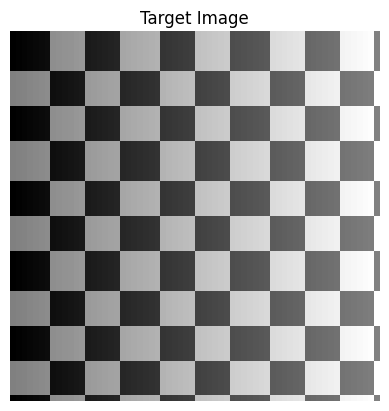

In [ ]:

# -----------------------------
# 1. Create a synthetic image
# -----------------------------

H, W = 64, 64  # image size
def make_image(H, W):
    """Generate a synthetic image: checkerboard + gradient."""
    x = torch.linspace(0, 1, W)
    y = torch.linspace(0, 1, H)
    grid_x, grid_y = torch.meshgrid(x, y, indexing="xy")
    checker = ((grid_x*10).floor().long() % 2) ^ ((grid_y*10).floor().long() % 2)
    gradient = grid_x
    img = 0.5*checker + 0.5*gradient
    return img.float()

img = make_image(H, W)

plt.imshow(img, cmap="gray")
plt.title("Target Image")
plt.axis("off")
plt.show()

# Prepare dataset: coords -> pixel intensity
coords = torch.stack(torch.meshgrid(
    torch.linspace(0, 1, H), torch.linspace(0, 1, W), indexing="ij"), dim=-1)
coords = coords.view(-1, 2)
target = img.view(-1, 1)


## Upload image [Optional]

Saving left.jpeg to left (1).jpeg


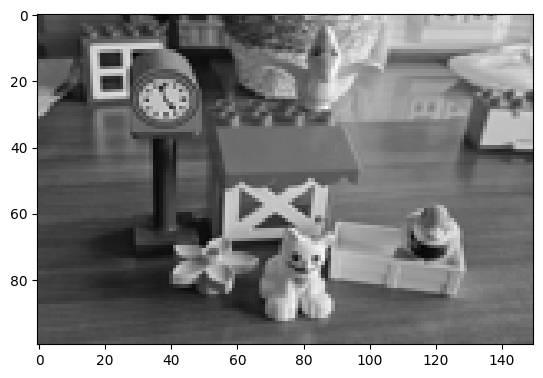

In [ ]:
from google.colab import files
from PIL import Image
import io

# Ask the user to upload an image
uploaded = files.upload()  # This opens a file picker in Colab

# Get the first uploaded file
for filename in uploaded.keys():
    # Open the image using PIL
    img = Image.open(io.BytesIO(uploaded[filename]))
    break  # Only take the first image

H, W = 150, 100  # image size
img_resized = img.resize((H, W))  # (width, height)

#Convert to tensor
import numpy as np
img_gray = img_resized.convert("L")                # Convert to grayscale
img_tensor = torch.tensor(np.array(img_gray), dtype=torch.float32)  # (H, W)

H, W = img_tensor.shape
img_tensor.view(-1,1)

# Display the image
plt.imshow(img_gray, cmap="gray")


Prepare coordinates data

In [ ]:
# Prepare coords
coords = torch.stack(torch.meshgrid(
    torch.linspace(0, 1, H),
    torch.linspace(0, 1, W),
    indexing="ij"
), dim=-1)
coords = coords.view(-1, 2)

# Print the shape first
print("coords shape:", coords.shape)
print("target shape:", target.shape)

# Print first few coordinates to avoid flooding output
print("First 10 coords:\n", coords[:10])
print("First 10 target values:\n", target[:10])

# Prepare target
target = img_tensor.view(-1, 1)  # Now this works


coords shape: torch.Size([15000, 2])
target shape: torch.Size([4096, 1])
First 10 coords:
 tensor([[0.0000, 0.0000],
        [0.0000, 0.0067],
        [0.0000, 0.0134],
        [0.0000, 0.0201],
        [0.0000, 0.0268],
        [0.0000, 0.0336],
        [0.0000, 0.0403],
        [0.0000, 0.0470],
        [0.0000, 0.0537],
        [0.0000, 0.0604]])
First 10 target values:
 tensor([[0.0000],
        [0.0079],
        [0.0159],
        [0.0238],
        [0.0317],
        [0.0397],
        [0.0476],
        [0.5556],
        [0.5635],
        [0.5714]])


## Define MLP

Explanation:

- A simple fully connected neural network (MLP).
- in_dim = number of input features (2 for plain coords, more with positional encoding).
- hidden = number of neurons per hidden layer.
- depth = number of hidden layers.
- Output = single value predicting pixel intensity.

In [ ]:
# -----------------------------
# 2. Define MLP
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=128, depth=3):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden))
            layers.append(nn.ReLU())
            d = hidden
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# -----------------------------
# 3. Training function
# ----------------------------
def train_model(model, X, Y, lr=1e-3, steps=2000):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for step in range(steps):
        pred = model(X)
        loss = loss_fn(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 500 == 0:
            print(f"Step {step}: loss = {loss.item():.4f}")
    return model


## Train without positional encoding
- Try to learn the image by directly using the input coordinates as input.
What do you observe?

<details>
<summary>✅ Click here to see the solution</summary>

```python
# -----------------------------
# 4. Train without positional encoding
# -----------------------------
mlp_plain = MLP(in_dim=2)
X_plain = coords
print("Training without positional encoding...")
mlp_plain = train_model(mlp_plain, X_plain, target)

# Reconstruct image
with torch.no_grad():
    recon_plain = mlp_plain(X_plain).view(H, W)
plt.imshow(recon_plain, cmap="gray")
plt.title("Reconstruction (Plain coords)")
plt.axis("off")
plt.show()

Training without positional encoding...
Step 0: loss = 13671.4746
Step 500: loss = 1431.1766
Step 1000: loss = 1098.3994
Step 1500: loss = 1056.3958


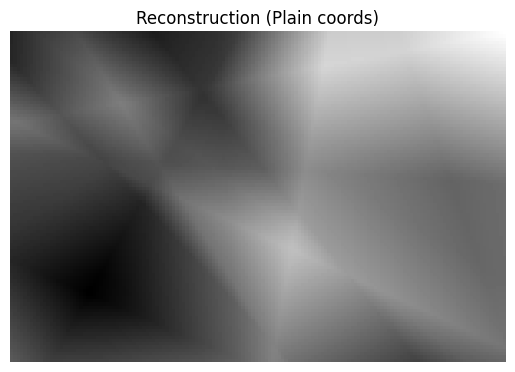

In [ ]:
# -----------------------------
# 4. Train without positional encoding
# -----------------------------
mlp_plain = MLP(in_dim=2)
X_plain = coords
print("Training without positional encoding...")
mlp_plain = train_model(...)

# Reconstruct image
with torch.no_grad():
    recon_plain = mlp_plain(...).view(H, W)
plt.imshow(recon_plain, cmap="gray")
plt.title("Reconstruction (Plain coords)")
plt.axis("off")
plt.show()

## Define positional encoding

In [ ]:
# -----------------------------
# 5. Positional Encoding
# -----------------------------
def positional_encoding(x, L=10):
    """Apply positional encoding to 2D coords x (N,2)."""
    enc = [x]
    for i in range(L):
        for fn in [torch.sin, torch.cos]:
            enc.append(fn((2.0**i) * torch.pi * x))
    return torch.cat(enc, dim=-1)


## Train with positional encoding

This code trains a MLP neural network to reconstruct the uploaded image using coordinates augmented with positional encoding. The training process attempts to learn a mapping from the encoded coordinates to the pixel intensities of the target image. The output image shows the model's ability to reconstruct the image with the help of positional encoding.

<details>
<summary>✅ Click here to see the solution</summary>

```python
# -----------------------------
# 6. Train with positional encoding
# -----------------------------
L = 10
mlp_pe = MLP(in_dim=2 + 2*2*L, hidden=128)  # 2 raw coords + sin/cos for L=10 per coord
X_pe = positional_encoding(coords, L)
print("Training with positional encoding...")
mlp_pe = train_model(mlp_pe, X_pe, target)

with torch.no_grad():
    #recon_pe = mlp_pe(X_pe).view(H, W)
    recon_pe = mlp_pe(X_pe).view(H, W)
plt.imshow(recon_pe, cmap="gray")
plt.title("Reconstruction (Positional Encoding)")
plt.axis("off")
plt.show()

Training with positional encoding...
Step 0: loss = 13688.6309
Step 500: loss = 734.0823
Step 1000: loss = 248.7963
Step 1500: loss = 71.9661


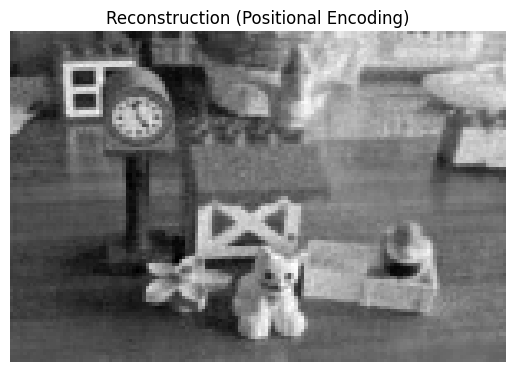

In [ ]:

# -----------------------------
# 6. Train with positional encoding
# -----------------------------
L = 10
mlp_pe = MLP(in_dim=2 + ..., hidden=128)  # 2 raw coords + sin/cos for L=10 per coord
X_pe = positional_encoding(coords, L)
print("Training with positional encoding...")
mlp_pe = train_model(...)

with torch.no_grad():
    #recon_pe = mlp_pe(X_pe).view(H, W)
    recon_pe = mlp_pe(X_pe).view(H, W)
plt.imshow(recon_pe, cmap="gray")
plt.title("Reconstruction (Positional Encoding)")
plt.axis("off")
plt.show()


Notice the influence of the number of hidden layers and the amount of frequencies L used in the final result.

- Try to compare different values of L and hidden layers.
- Does it converge faster or slower? Can you find an intuitive explanation for that?

<details>
<summary>✅ Click here to see the solution</summary>

```python
# -----------------------------
# 6b. Train with positional encoding
# -----------------------------
L = 20
mlp_pe_L20_h256 = MLP(in_dim=2 + 2*2*L, hidden=256)  # 2 raw coords + sin/cos for L=10 per coord
X_pe = positional_encoding(coords, L)
print("Training with positional encoding...")
mlp_pe_L20_h256 = train_model(mlp_pe_L20_h256, X_pe, target)

with torch.no_grad():
    #recon_pe = mlp_pe(X_pe).view(H, W)
    recon_pe_L20_h256 = mlp_pe_L20_h256(X_pe).view(H, W)
plt.imshow(recon_pe_L20_h256, cmap="gray")
plt.title("Reconstruction (Positional Encoding)")
plt.axis("off")
plt.show()

Training with positional encoding...
Step 0: loss = 13669.9160
Step 500: loss = 362.1333
Step 1000: loss = 16.4849
Step 1500: loss = 4.2693


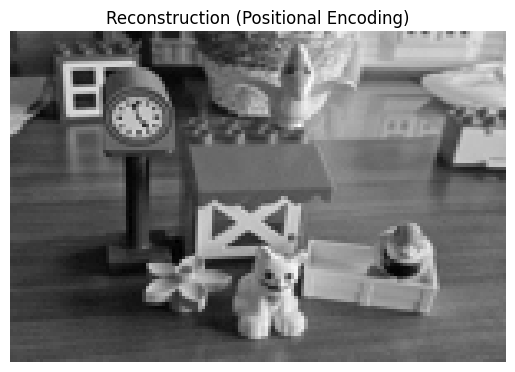

In [ ]:

# -----------------------------
# 6b. Train with positional encoding
# -----------------------------
L = 20
# TO DO: use 2 raw coords + sin/cos for L=10 per coord
# TO DO: increae hidden layers to 256
mlp_pe_L20_h256 = MLP(in_dim=2 + ..., hidden=...)  # 2 raw coords + sin/cos for L=10 per coord
X_pe = positional_encoding(coords, L)
print("Training with positional encoding...")
mlp_pe_L20_h256 = train_model(mlp_pe_L20_h256, X_pe, target)

with torch.no_grad():
    #recon_pe = mlp_pe(X_pe).view(H, W)
    recon_pe_L20_h256 = mlp_pe_L20_h256(X_pe).view(H, W)
plt.imshow(recon_pe_L20_h256, cmap="gray")
plt.title("Reconstruction (Positional Encoding)")
plt.axis("off")
plt.show()


## Visual comparison

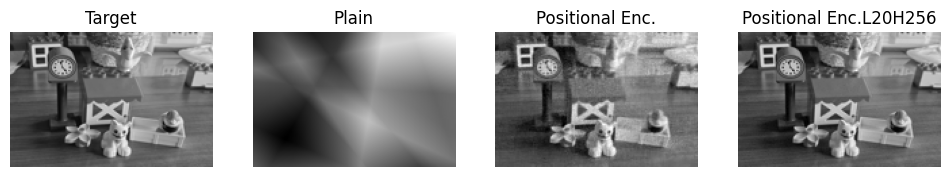

In [ ]:
# -----------------------------
# 7. Compare visually
# -----------------------------
fig, axs = plt.subplots(1, 4, figsize=(12,4))
axs[0].imshow(img_gray, cmap="gray"); axs[0].set_title("Target"); axs[0].axis("off")
axs[1].imshow(recon_plain, cmap="gray"); axs[1].set_title("Plain"); axs[1].axis("off")
axs[2].imshow(recon_pe, cmap="gray"); axs[2].set_title("Positional Enc."); axs[2].axis("off")
axs[3].imshow(recon_pe_L20_h256, cmap="gray"); axs[3].set_title("Positional Enc.L20H256"); axs[3].axis("off")
plt.show()